In [1]:
# 🔹 Celda 1: Backpropagation Explicado

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

print("=" * 60)
print("SEMANA 7: BACKPROPAGATION + PYTORCH")
print("=" * 60)

print("""
¿QUÉ ES BACKPROPAGATION?

Es la aplicación de CHAIN RULE (Semana 3) 
a través de una RED NEURONAL.

FORWARD PASS (calculamos predicción):
Input → W1 → z1 → σ → a1 → W2 → z2 → σ → Output

BACKWARD PASS (calculamos gradientes):
Loss ← ∂L/∂W2 ← ∂L/∂a1 ← ∂L/∂W1 ← Input

CHAIN RULE:
∂L/∂W1 = (∂L/∂z2) * (∂z2/∂a1) * (∂a1/∂z1) * (∂z1/∂W1)

PYTORCH lo AUTOMÁTICO para nosotros:
1. Define modelo
2. Forward pass (automático)
3. Calcula loss
4. .backward() (backprop automática)
5. Optimizer.step() (actualiza pesos)

¡NO TIENES QUE CALCULAR GRADIENTES MANUALMENTE!
""")

# Ejemplo simple: y = 2x² + 3x + 1
print("\n📊 EJEMPLO: Ajustar función cuadrática")
x = torch.randn(100, 1)
y = 2 * x**2 + 3 * x + 1 + torch.randn(100, 1) * 0.1

print(f"Data: {x.shape[0]} samples")
print(f"x range: [{x.min():.2f}, {x.max():.2f}]")
print(f"y range: [{y.min():.2f}, {y.max():.2f}]")


SEMANA 7: BACKPROPAGATION + PYTORCH

¿QUÉ ES BACKPROPAGATION?

Es la aplicación de CHAIN RULE (Semana 3) 
a través de una RED NEURONAL.

FORWARD PASS (calculamos predicción):
Input → W1 → z1 → σ → a1 → W2 → z2 → σ → Output

BACKWARD PASS (calculamos gradientes):
Loss ← ∂L/∂W2 ← ∂L/∂a1 ← ∂L/∂W1 ← Input

CHAIN RULE:
∂L/∂W1 = (∂L/∂z2) * (∂z2/∂a1) * (∂a1/∂z1) * (∂z1/∂W1)

PYTORCH lo AUTOMÁTICO para nosotros:
1. Define modelo
2. Forward pass (automático)
3. Calcula loss
4. .backward() (backprop automática)
5. Optimizer.step() (actualiza pesos)

¡NO TIENES QUE CALCULAR GRADIENTES MANUALMENTE!


📊 EJEMPLO: Ajustar función cuadrática
Data: 100 samples
x range: [-3.13, 2.15]
y range: [-0.20, 16.72]


In [2]:
# 🔹 Celda 2: Red Neuronal en PyTorch

print("\n" + "=" * 60)
print("RED NEURONAL EN PYTORCH")
print("=" * 60)

# Definir modelo
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(1, 64)      # Input: 1, Output: 64
        self.fc2 = nn.Linear(64, 32)     # 64 → 32
        self.fc3 = nn.Linear(32, 1)      # 32 → 1
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))      # ReLU activation
        x = torch.relu(self.fc2(x))      # ReLU activation
        x = self.fc3(x)                  # Output (lineal)
        return x

model = SimpleNN()
print(f"\n🏗️ Modelo:")
print(model)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
print(f"\n📊 Parámetros totales: {total_params}")

# Loss function y optimizador
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(f"\n⚙️ Loss: MSE")
print(f"⚙️ Optimizer: Adam (lr=0.01)")



RED NEURONAL EN PYTORCH

🏗️ Modelo:
SimpleNN(
  (fc1): Linear(in_features=1, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

📊 Parámetros totales: 2241

⚙️ Loss: MSE
⚙️ Optimizer: Adam (lr=0.01)



TRAINING LOOP (BACKPROPAGATION AUTOMÁTICA)
Entrenando por 500 epochs...

Epoch 50/500: Loss=0.230959
Epoch 100/500: Loss=0.044501
Epoch 150/500: Loss=0.022882
Epoch 200/500: Loss=0.012733
Epoch 250/500: Loss=0.009278
Epoch 300/500: Loss=0.007806
Epoch 350/500: Loss=0.007155
Epoch 400/500: Loss=0.006841
Epoch 450/500: Loss=0.006654
Epoch 500/500: Loss=0.006485

✅ Training complete!
Loss final: 0.006485


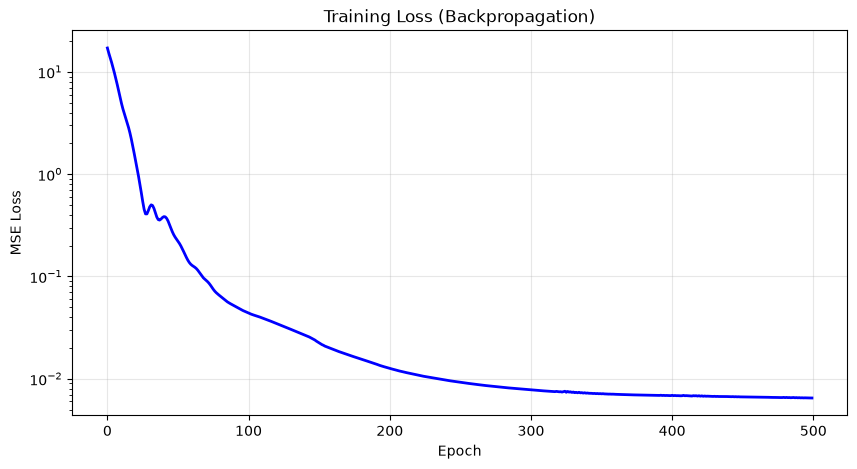

In [3]:
# 🔹 Celda 3: Training Loop

print("\n" + "=" * 60)
print("TRAINING LOOP (BACKPROPAGATION AUTOMÁTICA)")
print("=" * 60)

epochs = 500
losses = []

print(f"Entrenando por {epochs} epochs...\n")

for epoch in range(epochs):
    # Forward pass
    y_pred = model(x)
    loss = criterion(y_pred, y)
    losses.append(loss.item())
    
    # Backward pass (BACKPROPAGATION AUTOMÁTICA)
    optimizer.zero_grad()  # Limpiar gradientes
    loss.backward()        # ← BACKPROPAGATION (calcula todos los gradientes)
    optimizer.step()       # Actualizar pesos
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}: Loss={loss.item():.6f}")

print(f"\n✅ Training complete!")
print(f"Loss final: {losses[-1]:.6f}")

# Visualizar loss curve
plt.figure(figsize=(10, 5))
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss (Backpropagation)')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show()



PREDICCIONES Y VISUALIZACIÓN


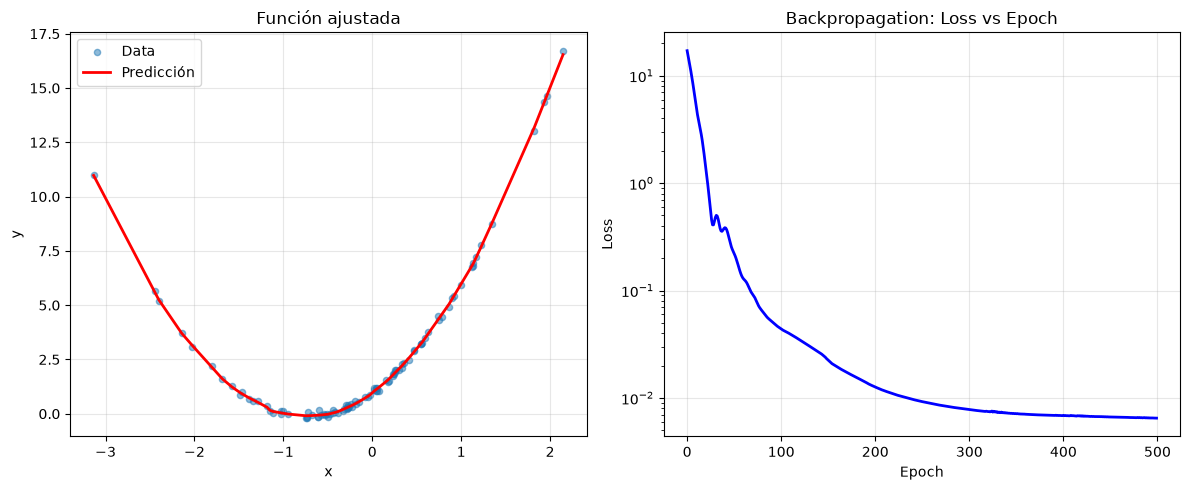


MSE final: 0.006479


In [4]:
# 🔹 Celda 4: Predicciones

print("\n" + "=" * 60)
print("PREDICCIONES Y VISUALIZACIÓN")
print("=" * 60)

model.eval()  # Modo evaluación
with torch.no_grad():
    y_pred_final = model(x).numpy()

# Visualizar
plt.figure(figsize=(12, 5))

# Datos vs predicción
plt.subplot(1, 2, 1)
plt.scatter(x.numpy(), y.numpy(), alpha=0.5, s=20, label='Data')
idx = np.argsort(x.numpy().flatten())
plt.plot(x.numpy()[idx], y_pred_final[idx], 'r-', linewidth=2, label='Predicción')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Función ajustada')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Backpropagation: Loss vs Epoch')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular error final
mse_final = nn.MSELoss()(torch.tensor(y_pred_final, dtype=torch.float32), y)
print(f"\nMSE final: {mse_final.item():.6f}")


In [5]:
# 🔹 Celda 5: Backprop Manual vs PyTorch

print("\n" + "=" * 60)
print("COMPARACIÓN: MANUAL vs PYTORCH")
print("=" * 60)

print("""
BACKPROPAGATION MANUAL (Semana 6):
├─ Calculas ∂L/∂W manualmente
├─ Código complejo y propenso a errores
├─ 100+ líneas para 2 capas
├─ Entiendes cada derivada
└─ Pero LENTO y difícil de escalar

PYTORCH AUTOMÁTICO (Semana 7):
├─ .backward() calcula TODO automáticamente
├─ Autograd: diferenciación automática
├─ 10 líneas para cualquier red
├─ NO necesitas saber cálculo internamente
└─ RÁPIDO y escala a 1000s de capas

VENTAJA: PyTorch abstrae complejidad
DESVENTAJA: Menos control fino

Para PRODUCCIÓN: PyTorch
Para APRENDER: Ambos (primero manual, después PyTorch)
""")

# Mostrar que los gradientes existen
print(f"\n📊 GRADIENTES CALCULADOS AUTOMÁTICAMENTE:")
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"{name}: grad shape={param.grad.shape}, grad_mean={param.grad.mean():.6f}")



COMPARACIÓN: MANUAL vs PYTORCH

BACKPROPAGATION MANUAL (Semana 6):
├─ Calculas ∂L/∂W manualmente
├─ Código complejo y propenso a errores
├─ 100+ líneas para 2 capas
├─ Entiendes cada derivada
└─ Pero LENTO y difícil de escalar

PYTORCH AUTOMÁTICO (Semana 7):
├─ .backward() calcula TODO automáticamente
├─ Autograd: diferenciación automática
├─ 10 líneas para cualquier red
├─ NO necesitas saber cálculo internamente
└─ RÁPIDO y escala a 1000s de capas

VENTAJA: PyTorch abstrae complejidad
DESVENTAJA: Menos control fino

Para PRODUCCIÓN: PyTorch
Para APRENDER: Ambos (primero manual, después PyTorch)


📊 GRADIENTES CALCULADOS AUTOMÁTICAMENTE:
fc1.weight: grad shape=torch.Size([64, 1]), grad_mean=0.000034
fc1.bias: grad shape=torch.Size([64]), grad_mean=-0.000170
fc2.weight: grad shape=torch.Size([32, 64]), grad_mean=-0.000022
fc2.bias: grad shape=torch.Size([32]), grad_mean=-0.000077
fc3.weight: grad shape=torch.Size([1, 32]), grad_mean=-0.000704
fc3.bias: grad shape=torch.Size([1]), grad_